In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style parameters for graphics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("📦 Libraries imported and visual settings initialized successfully!")

📦 Libraries imported and visual settings initialized successfully!


In [ ]:
print("--- Step 1: Loading and Inspecting the Dataset ---")
# Read your converted CSV dataset
df = pd.read_csv("OlympicAthletes.csv")

# Print dataset size properties
print(f"Dataset Size: {df.shape[0]} rows, {df.shape[1]} columns\n")

print("--- Column Configurations & Non-Null Counts ---")
print(df.info())

print("\n--- Summary of Empty (Missing) Values per Feature Field ---")
print(df.isnull().sum())

--- Step 1: Loading and Inspecting the Dataset ---
Dataset Size: 8618 rows, 10 columns

--- Column Configurations & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Athlete                8613 non-null   object 
 1   Age                    8613 non-null   float64
 2   Country                8618 non-null   object 
 3   Year                   8618 non-null   int64  
 4   Closing Ceremony Date  8618 non-null   object 
 5   Sport                  8618 non-null   object 
 6   Gold Medals            8618 non-null   int64  
 7   Silver Medals          8618 non-null   int64  
 8   Bronze Medals          8618 non-null   int64  
 9   Total Medals           8618 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 673.4+ KB
None

--- Summary of Empty (Missing) Values per Feature Field ---
Ath

In [ ]:
print("--- Step 2: Processing and Cleaning Data ---")

# 1. Fill missing Age values with the middle evaluation metric (median)
median_value = df['Age'].median()
df['Age'] = df['Age'].fillna(median_value)
print(f"✅ Handled missing values: Replaced empty 'Age' blocks with dataset median ({median_value})")

# 2. Identify and drop exact row duplications
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✅ Handled duplicates: Purged {duplicates} identical duplicate rows from memory.")
else:
    print("✅ Handled duplicates: Checked structural data; no identical row duplicates found.")

# 3. Standardize time format fields
df['Closing Ceremony Date'] = pd.to_datetime(df['Closing Ceremony Date'], errors='coerce')

print("\n🎉 Preprocessing done! Cleaned data snapshot:")
df.head()

--- Step 2: Processing and Cleaning Data ---
✅ Handled missing values: Replaced empty 'Age' blocks with dataset median (26.0)
✅ Handled duplicates: Purged 3 identical duplicate rows from memory.

🎉 Preprocessing done! Cleaned data snapshot:


,Athlete,Age,Country,Year,Closing Ceremony Date,Sport,Gold Medals,Silver Medals,Bronze Medals,Total Medals
0,Michael Phelps,23.0,United States,2008,2008-08-24,Swimming,8,0,0,8
1,Michael Phelps,19.0,United States,2004,2004-08-29,Swimming,6,0,2,8
2,Michael Phelps,27.0,United States,2012,2012-08-12,Swimming,4,2,0,6
3,Natalie Coughlin,25.0,United States,2008,2008-08-24,Swimming,1,2,3,6
4,Aleksey Nemov,24.0,Russia,2000,2000-10-01,Gymnastics,2,1,3,6


In [ ]:
print("--- Step 3: Statistical Summary Calculations ---")

# Compute numerical distribution metrics (mean, min, max, standard deviation)
print("💡 Descriptive Features Breakdown:")
display(df.describe())

# Group matching values to pull key insights
print("\n🏅 Elite Performers: Top 5 Athletes by Accumulated Total Medals:")
top_performers = df.groupby('Athlete')['Total Medals'].sum().sort_values(ascending=False).head(5)
print(top_performers)

print("\n🌍 Global Dominance: Top 5 Countries by Overall Gold Medal Counts:")
top_countries = df.groupby('Country')['Gold Medals'].sum().sort_values(ascending=False).head(5)
print(top_countries)

--- Step 3: Statistical Summary Calculations ---
💡 Descriptive Features Breakdown:


,Age,Year,Closing Ceremony Date,Gold Medals,Silver Medals,Bronze Medals,Total Medals
count,8615.00000,8615.000000,8615,8615.000000,8615.000000,8615.000000,8615.000000
mean,26.40534,2005.976785,2006-07-26 20:14:20.824144128,0.364829,0.363088,0.377829,1.105746
min,15.00000,2000.000000,2000-10-01 00:00:00,0.000000,0.000000,0.000000,1.000000
25%,23.00000,2002.000000,2002-02-24 00:00:00,0.000000,0.000000,0.000000,1.000000
50%,26.00000,2006.000000,2006-02-26 00:00:00,0.000000,0.000000,0.000000,1.000000
75%,29.00000,2010.000000,2010-02-28 00:00:00,1.000000,1.000000,1.000000,1.000000
max,61.00000,2012.000000,2012-08-12 00:00:00,8.000000,3.000000,3.000000,8.000000
std,5.10153,4.289221,NaN,0.545401,0.511564,0.505044,0.408958



🏅 Elite Performers: Top 5 Athletes by Accumulated Total Medals:
Athlete
Michael Phelps      22
Natalie Coughlin    12
Ryan Lochte         11
Ian Thorpe           9
Leisel Jones         9
Name: Total Medals, dtype: int64

🌍 Global Dominance: Top 5 Countries by Overall Gold Medal Counts:
Country
United States    552
China            234
Russia           234
Germany          223
Canada           168
Name: Gold Medals, dtype: int64


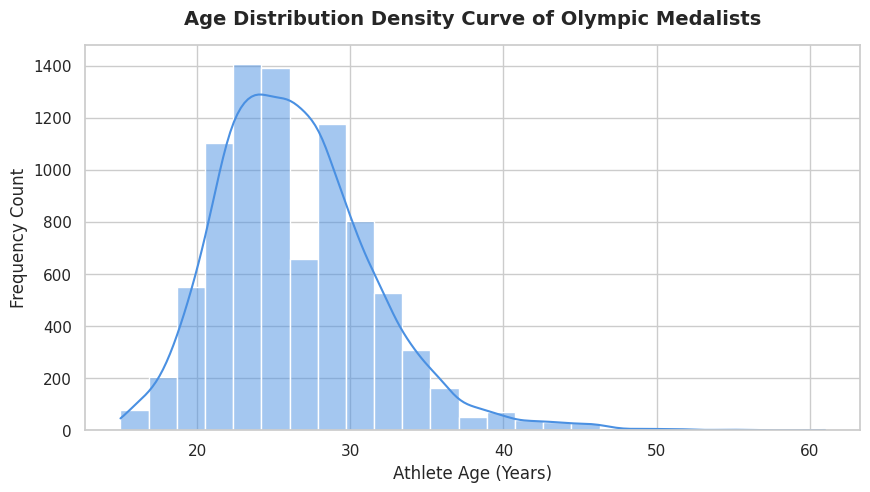

In [ ]:
# Create Figure
plt.figure(figsize=(10, 5))

# Generate Histogram Overlay with a kernel density estimate curve
sns.histplot(df['Age'], bins=25, kde=True, color='#4A90E2')

plt.title('Age Distribution Density Curve of Olympic Medalists', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Athlete Age (Years)', fontsize=12)
plt.ylabel('Frequency Count', fontsize=12)

plt.show()

/tmp/ipykernel_7435/1508132800.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_nations.values, y=top_10_nations.index, palette='viridis')


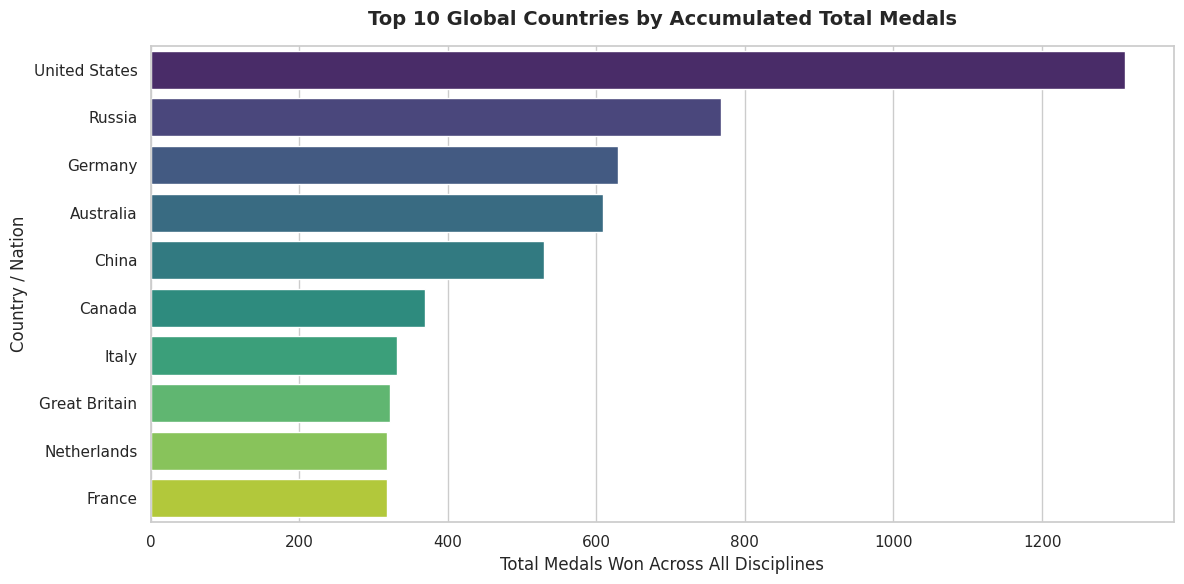

In [ ]:
# Create Figure
plt.figure(figsize=(12, 6))

# Calculate data metrics for plotting
top_10_nations = df.groupby('Country')['Total Medals'].sum().sort_values(ascending=False).head(10)

# Build horizontal bar layout plot
sns.barplot(x=top_10_nations.values, y=top_10_nations.index, palette='viridis')

plt.title('Top 10 Global Countries by Accumulated Total Medals', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Medals Won Across All Disciplines', fontsize=12)
plt.ylabel('Country / Nation', fontsize=12)
plt.tight_layout()

plt.show()

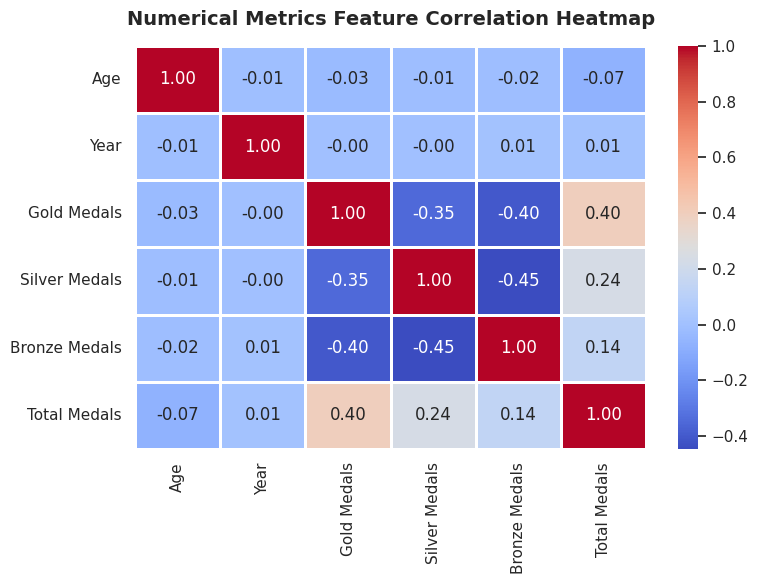

In [ ]:
# Create Figure
plt.figure(figsize=(8, 6))

# Filter out non-numeric attributes for correlation calculation
numeric_features = ['Age', 'Year', 'Gold Medals', 'Silver Medals', 'Bronze Medals', 'Total Medals']
correlation_matrix = df[numeric_features].corr()

# Construct annotated matrix layout map
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.8, cbar=True)

plt.title('Numerical Metrics Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

print("--- Step 5: Feature Engineering & Categorical Encoding ---")

# 1. Define our target goal: 1 if the athlete won at least 1 Gold Medal, 0 if they won alternative medals
df['Won_Gold'] = df['Gold Medals'].apply(lambda x: 1 if x > 0 else 0)

# 2. Select predictive features (avoiding 'Total Medals' or 'Gold Medals' to prevent data leakage)
features = ['Age', 'Country', 'Sport', 'Silver Medals', 'Bronze Medals']
X = df[features].copy()
y = df['Won_Gold']

# 3. Initialize a dictionary to store our encoders for later use in Streamlit
encoders = {}

for col in ['Country', 'Sport']:
    le = LabelEncoder()
    # Convert column to string to prevent mismatch errors and fit transform
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

print("✅ Features extracted and text variables mapped to machine-readable numbers.")
print("Independent features matrix preview:")
display(X.head())

--- Step 5: Feature Engineering & Categorical Encoding ---
✅ Features extracted and text variables mapped to machine-readable numbers.
Independent features matrix preview:


,Age,Country,Sport,Silver Medals,Bronze Medals
0,23.0,104,38,0,0
1,19.0,104,38,0,2
2,27.0,104,38,2,0
3,25.0,104,38,2,3
4,24.0,80,20,1,3


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

print("--- Step 6: Dataset Splitting & Model Training ---")

# 1. Split data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

# 2. Initialize and fit the Supervised Random Forest Classifier
print("\n🤖 Training the Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
model.fit(X_train, y_train)

print("🎉 Model training process completed successfully!")

--- Step 6: Dataset Splitting & Model Training ---
Training features shape: (6892, 5)
Testing features shape: (1723, 5)

🤖 Training the Random Forest Classifier...
🎉 Model training process completed successfully!


--- Step 7: Final Model Evaluation Metrics ---
📊 Accuracy Score: 95.88%

📋 Comprehensive Classification Metrics Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1127
           1       0.99      0.89      0.94       596

    accuracy                           0.96      1723
   macro avg       0.97      0.94      0.95      1723
weighted avg       0.96      0.96      0.96      1723


🖼️ Confusion Matrix Heatmap Representation:


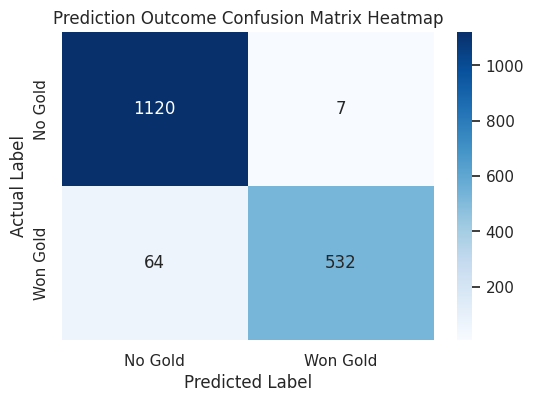

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("--- Step 7: Final Model Evaluation Metrics ---")

# 1. Generate predictions from our validation test split
y_pred = model.predict(X_test)

# 2. Compute structural calculations
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"📊 Accuracy Score: {accuracy * 100:.2f}%\n")
print("📋 Comprehensive Classification Metrics Report:")
print(classification_report(y_test, y_pred))

# 3. Plotting the Confusion Matrix visually
print("\n🖼️ Confusion Matrix Heatmap Representation:")
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Gold', 'Won Gold'], yticklabels=['No Gold', 'Won Gold'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Prediction Outcome Confusion Matrix Heatmap')
plt.show()